Loaded: saved_data\demo\simulator_data\session_001\session_001_20260408_044239_all.csv
Shape: 5670 samples x 26 columns
Columns: ['timestamp', 'index', 'adc0_gpio36', 'adc1_gpio39', 'adc2_gpio34', 'adc3_gpio35', 'adc4_gpio32', 'adc5_gpio33', 'imu0_acc_x', 'imu0_acc_y', 'imu0_acc_z', 'imu0_gyro_x', 'imu0_gyro_y', 'imu0_gyro_z', 'imu0_mag_x', 'imu0_mag_y', 'imu0_mag_z', 'imu1_acc_x', 'imu1_acc_y', 'imu1_acc_z', 'imu1_gyro_x', 'imu1_gyro_y', 'imu1_gyro_z', 'imu1_mag_x', 'imu1_mag_y', 'imu1_mag_z']


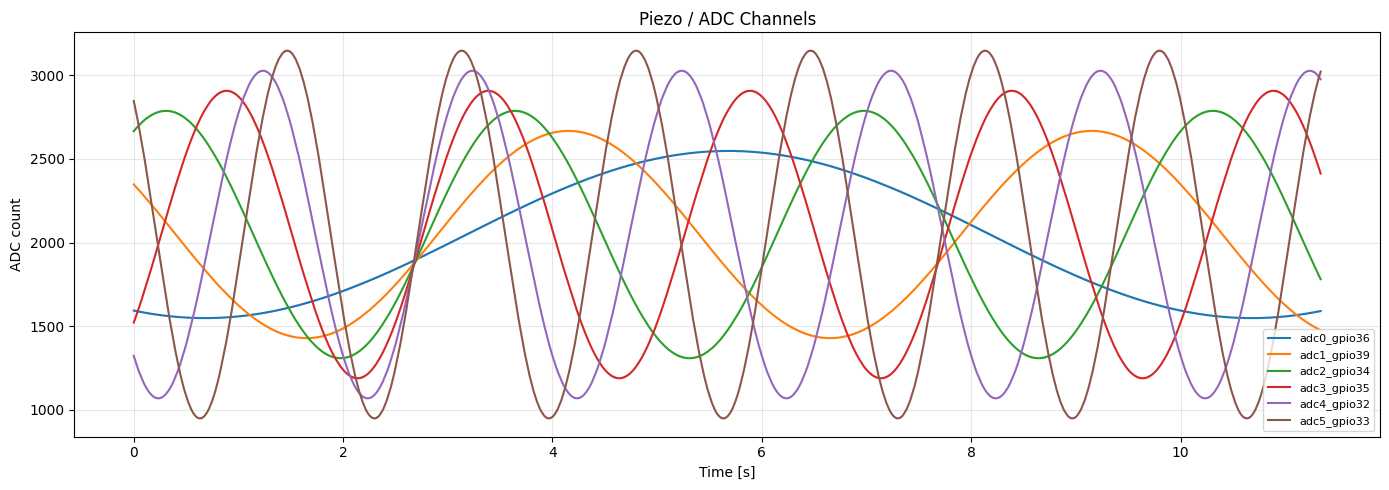

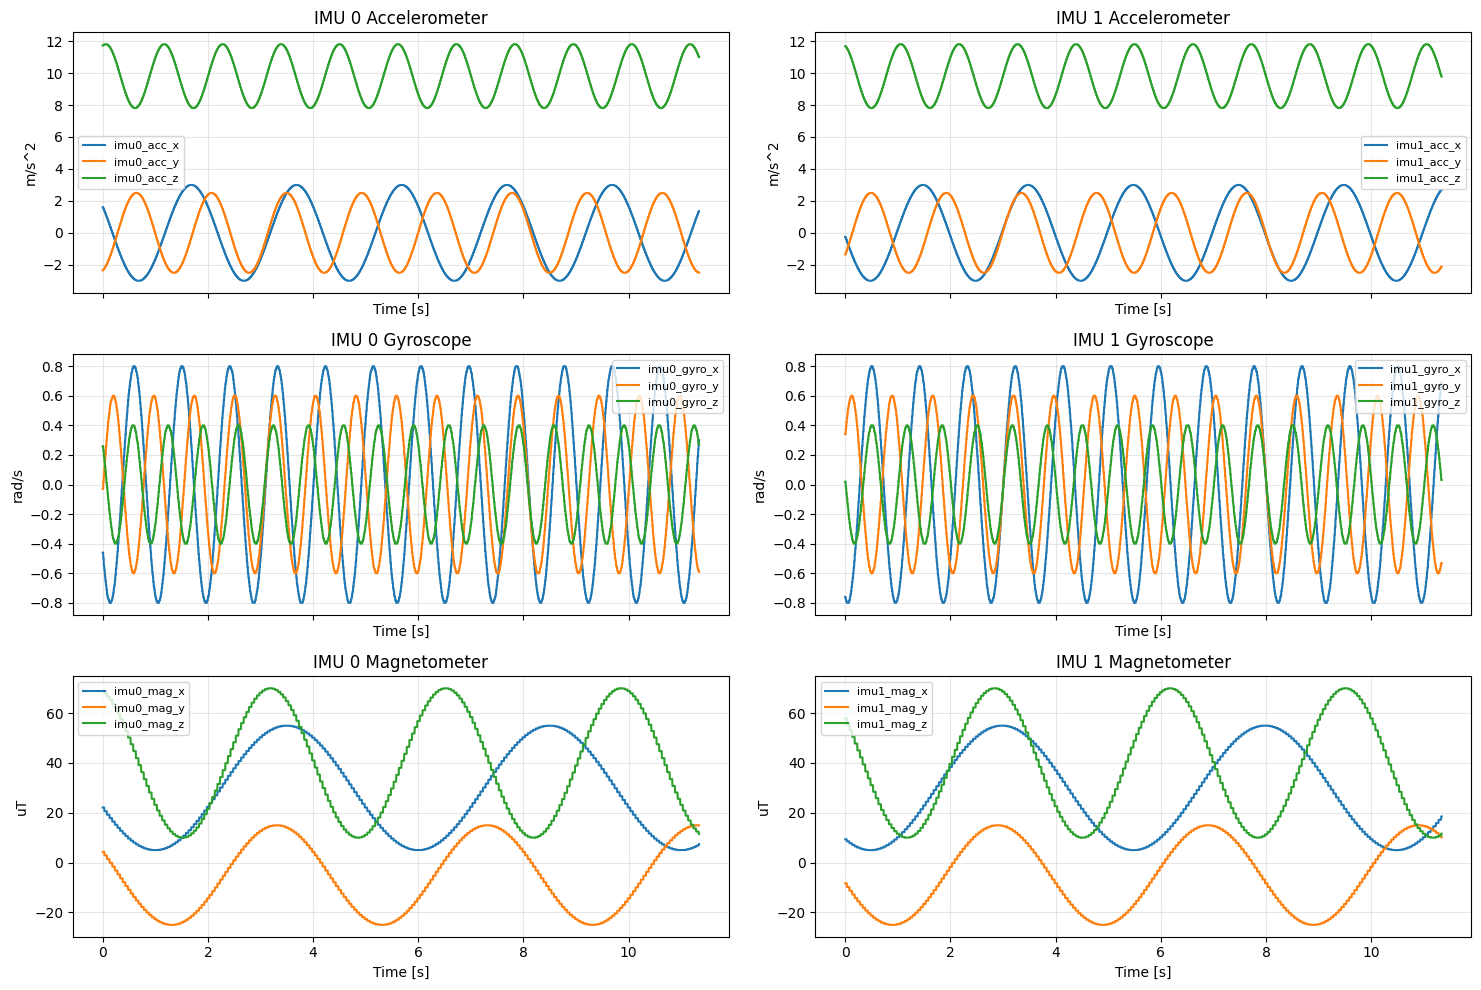

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# ---- CONFIG ----
# Leave CSV_FILE as None to use the newest combined CSV under saved_data/.
# Or set it explicitly, for example:
# CSV_FILE = "saved_data/demo/simulation/session_001/session_001_20260408_034549_all.csv"
CSV_FILE = None
SAVED_DATA_ROOT = Path("saved_data")


def find_latest_combined_csv(root=SAVED_DATA_ROOT):
    files = list(root.rglob("*_all.csv"))
    if not files:
        raise FileNotFoundError(f"No *_all.csv files found under {root.resolve()}")
    return max(files, key=lambda path: path.stat().st_mtime)


def existing_columns(df, columns):
    return [col for col in columns if col in df.columns]


def plot_columns(ax, df, t, columns, title, ylabel):
    plotted = False
    for col in existing_columns(df, columns):
        ax.plot(t, df[col], label=col)
        plotted = True

    ax.set_title(title)
    ax.set_xlabel("Time [s]")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    if plotted:
        ax.legend(loc="best", fontsize=8)
    else:
        ax.text(0.5, 0.5, "No matching columns", transform=ax.transAxes, ha="center", va="center")


def main():
    csv_path = Path(CSV_FILE) if CSV_FILE else find_latest_combined_csv()
    df = pd.read_csv(csv_path)

    print(f"Loaded: {csv_path}")
    print(f"Shape: {df.shape[0]} samples x {df.shape[1]} columns")
    print("Columns:", list(df.columns))

    if "timestamp" not in df.columns:
        raise ValueError("Expected a 'timestamp' column in the combined DataLogger CSV.")

    t = df["timestamp"]
    adc_cols = [f"adc{i}_gpio{gpio}" for i, gpio in enumerate([36, 39, 34, 35, 32, 33])]
    acc_axes = ["acc_x", "acc_y", "acc_z"]
    gyro_axes = ["gyro_x", "gyro_y", "gyro_z"]
    mag_axes = ["mag_x", "mag_y", "mag_z"]

    # ---------- Figure 1: six piezo / ADC channels ----------
    fig, ax = plt.subplots(figsize=(14, 5))
    plot_columns(ax, df, t, adc_cols, "Piezo / ADC Channels", "ADC count")
    fig.tight_layout()

    # ---------- Figure 2: IMU0 and IMU1, grouped by sensor and signal type ----------
    fig, axes = plt.subplots(3, 2, figsize=(15, 10), sharex=True)
    for imu_idx in range(2):
        plot_columns(
            axes[0, imu_idx],
            df,
            t,
            [f"imu{imu_idx}_{axis}" for axis in acc_axes],
            f"IMU {imu_idx} Accelerometer",
            "m/s^2",
        )
        plot_columns(
            axes[1, imu_idx],
            df,
            t,
            [f"imu{imu_idx}_{axis}" for axis in gyro_axes],
            f"IMU {imu_idx} Gyroscope",
            "rad/s",
        )
        plot_columns(
            axes[2, imu_idx],
            df,
            t,
            [f"imu{imu_idx}_{axis}" for axis in mag_axes],
            f"IMU {imu_idx} Magnetometer",
            "uT",
        )

    fig.tight_layout()
    plt.show()


main()
